In [1]:
import os
import scipy
import numpy
from matplotlib import pyplot

In [2]:
# Path
TAG = 'Y10'
LABEL = 'KERNEL'
FOLDER = '/global/cfs/cdirs/lsst/groups/MCP/CosmoCloud/LimberCloud/'

INFO_FOLDER = os.path.join(FOLDER, 'INFO')
DATA_FOLDER = os.path.join(FOLDER, 'DATA', TAG)
PLOT_FOLDER = os.path.join(FOLDER, 'PLOT', LABEL, TAG)

In [3]:
# Grid
Z1 = 0.0
Z2 = 3.5
GRID_SIZE = 350
Z_GRID = numpy.linspace(Z1, Z2, GRID_SIZE + 1)

# Lens
LENS = numpy.load(os.path.join(DATA_FOLDER, 'lsst_lens_bins.npy'), allow_pickle=True).item()
LENS_REDSHIFT = LENS['redshift_range']
LENS_BIN_SIZE = len(LENS['bins'])

LENS_PSI_GRID = numpy.zeros((LENS_BIN_SIZE, GRID_SIZE + 1))
for BIN_INDEX in range(LENS_BIN_SIZE):
    LENS_PSI_GRID[BIN_INDEX, :] = numpy.interp(x=Z_GRID, xp=LENS_REDSHIFT, fp=LENS['bins'][BIN_INDEX])
LENS_PSI_GRID = LENS_PSI_GRID / scipy.integrate.trapezoid(x=Z_GRID, y=LENS_PSI_GRID, axis=1)[:, numpy.newaxis]

# Source
SOURCE = numpy.load(os.path.join(DATA_FOLDER, 'lsst_source_bins.npy'), allow_pickle=True).item()
SOURCE_REDSHIFT = SOURCE['redshift_range']
SOURCE_BIN_SIZE = len(SOURCE['bins'])

SOURCE_PSI_GRID = numpy.zeros((SOURCE_BIN_SIZE, GRID_SIZE + 1))
for BIN_INDEX in range(SOURCE_BIN_SIZE):
    SOURCE_PSI_GRID[BIN_INDEX, :] = numpy.interp(x=Z_GRID, xp=SOURCE_REDSHIFT, fp=SOURCE['bins'][BIN_INDEX])
SOURCE_PSI_GRID = SOURCE_PSI_GRID / scipy.integrate.trapezoid(x=Z_GRID, y=SOURCE_PSI_GRID, axis=1)[:, numpy.newaxis]

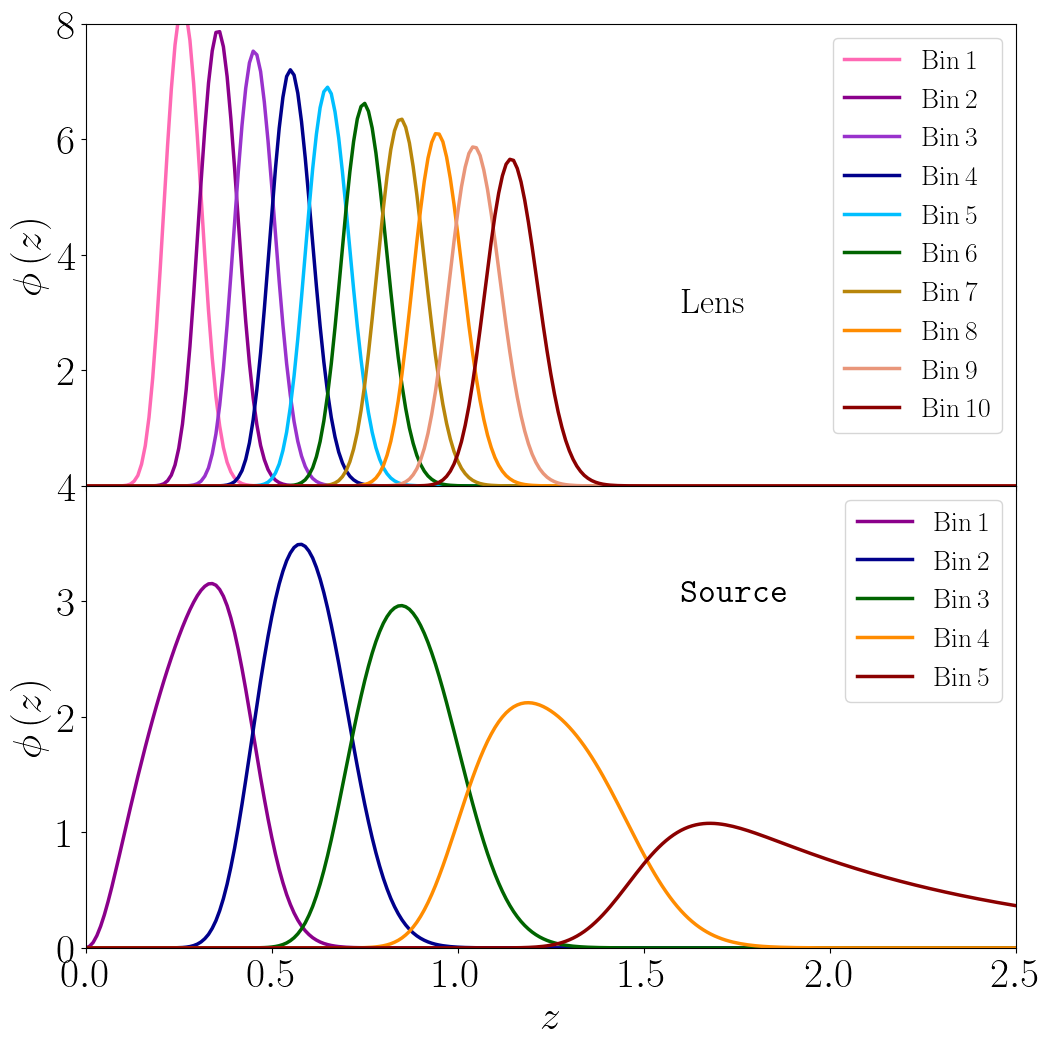

In [4]:
os.environ['PATH'] = '/pscratch/sd/y/yhzhang/texlive/2025/bin/x86_64-linux:' + os.environ['PATH']
pyplot.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
pyplot.rcParams['pgf.texsystem'] = 'pdflatex'
pyplot.rcParams['text.usetex'] = True
pyplot.rcParams['font.size'] = 30

FIGURE, PLOT = pyplot.subplots(nrows = 2, ncols = 1, figsize = (12, 12))
COLOR_SOURCE_LIST = ['darkmagenta', 'darkblue', 'darkgreen', 'darkorange', 'darkred']
COLOR_LENS_LIST = ['hotpink','darkmagenta', 'darkorchid', 'darkblue', 'deepskyblue', 'darkgreen', 'darkgoldenrod', 'darkorange', 'darksalmon', 'darkred']

for BIN_INDEX in range(LENS_BIN_SIZE):
    PLOT[0].plot(Z_GRID, LENS_PSI_GRID[BIN_INDEX, :], color = COLOR_LENS_LIST[BIN_INDEX], linewidth = 2.5, label=r'$\mathrm{Bin} \,' + r'{:.0f}$'.format(BIN_INDEX + 1), rasterized=True)

PLOT[0].set_xlim(0.0, 2.5)
PLOT[0].set_ylim(0.0, 8.0)

PLOT[0].set_xticklabels([])
PLOT[0].set_yticks([2.0, 4.0, 6.0, 8.0])
PLOT[0].legend(loc='upper right', fontsize=20)

PLOT[0].set_ylabel(r'$\phi \left( z \right)$')
PLOT[0].text(x=1.6, y=3.0, s=r'$\mathrm{Lens}$', fontsize=25)

for BIN_INDEX in range(SOURCE_BIN_SIZE):
    PLOT[1].plot(Z_GRID, SOURCE_PSI_GRID[BIN_INDEX, :], color = COLOR_SOURCE_LIST[BIN_INDEX], linewidth = 2.5, label=r'$\mathrm{Bin} \,' + r'{:.0f}$'.format(BIN_INDEX + 1), rasterized=True)

PLOT[1].set_xlim(0.0, 2.5)
PLOT[1].set_ylim(0.0, 4.0)

PLOT[1].set_yticks([0.0, 1.0, 2.0, 3.0, 4.0])
PLOT[1].legend(loc='upper right', fontsize=20)

PLOT[1].set_xlabel(r'$z$')
PLOT[1].set_ylabel(r'$\phi \left( z \right)$')
PLOT[1].text(x=1.6, y=3.0, s=r'$\mathtt{Source}$', fontsize=25)

FIGURE.subplots_adjust(hspace=0.0)
FIGURE.savefig(os.path.join(PLOT_FOLDER, 'PSI.pdf'), bbox_inches='tight')